# Análisis Exploratorio de Datos (EDA) — Clasificador de Reclamos Municipales

Este notebook realiza el análisis exploratorio del dataset sintético de reclamos
municipales (`data/reclamos.csv`), correspondiente al **criterio 3.1 — Diseño de
solución ML** de la rúbrica de evaluación.

**Objetivos del EDA:**

1. Verificar la calidad de los datos (nulos, duplicados, tipos).
2. Analizar el balance de clases entre las 6 categorías.
3. Caracterizar la longitud y el vocabulario de los reclamos.
4. Documentar los hallazgos que **justifican las decisiones de preprocesamiento
   y de modelo** (TF-IDF + Naive Bayes / Logistic Regression), que se detallan
   con mayor profundidad en `README.md` y se implementan en `src/train.py`.


In [1]:
import re
import unicodedata

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
%matplotlib inline


## 1. Carga de datos

In [2]:
df = pd.read_csv("../data/reclamos.csv")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head(10)


Dimensiones del dataset: 700 filas x 2 columnas


,texto,categoria
0,los vecinos del sector sur estamos organizando rondas propias porque los robos no paran y la municipalidad no ha res...,Seguridad Ciudadana
1,"hay un galpon en Poblacion Nueva Amanecer que funciona como bodega sin permiso de funcionamiento, ademas genera much...",Permisos y Patentes Comerciales
2,quiero reclamar xq los contenedores de basura de mi calle estan siempre rebalsados y los perros vagos rompen las bol...,Aseo y Ornato
3,"el sitio eriazo de calle Padre Hurtado se ha convertido en un foco de delincuencia, de noche se juntan a robar y a c...",Seguridad Ciudadana
4,la vereda del centro esta toda levantada por las raices de un arbol y varias personas se han caido ahi. Saludos!!,Vialidad y Pavimentación
5,"reclamo xq el furgon de seguridad municipal ya no pasa por el sector poniente como antes, y justo ahora es cuando ma...",Seguridad Ciudadana
6,los postes de luz de la cuadra de la plaza se apagan como a las 11 de la noche y quedamos completamente a oscuras ha...,Alumbrado Público
7,"el pavimento de calle Los Copihues esta totalmente destrozado, cada vez q llueve se llena de agua y no se puede pasa...",Vialidad y Pavimentación
8,hicieron una rayado (graffiti) horrible en el muro de la sede social de Poblacion 18 de Septiembre y ya lleva bastan...,Aseo y Ornato
9,quiero saber pq el local de calle Los Alamos sigue abierto si los vecinos ya denunciamos que no tiene patente comerc...,Permisos y Patentes Comerciales


## 2. Calidad de los datos

Antes de cualquier análisis hay que confirmar que el dataset no tiene
problemas basicos: valores nulos, columnas con tipos incorrectos o registros
duplicados que podrian inflar artificialmente el desempeño del modelo si
aparecen tanto en train como en test.


In [3]:
print("Tipos de datos:")
print(df.dtypes)
print()

print("Valores nulos por columna:")
print(df.isnull().sum())
print()

print(f"Filas totalmente duplicadas (texto + categoria): {df.duplicated().sum()}")
print(f"Textos duplicados (solo columna 'texto'): {df['texto'].duplicated().sum()}")
print(f"Categorias unicas: {sorted(df['categoria'].unique())}")


Tipos de datos:
texto        str
categoria    str
dtype: object

Valores nulos por columna:
texto        0
categoria    0
dtype: int64

Filas totalmente duplicadas (texto + categoria): 0
Textos duplicados (solo columna 'texto'): 0
Categorias unicas: ['Alumbrado Público', 'Aseo y Ornato', 'Permisos y Patentes Comerciales', 'Seguridad Ciudadana', 'Vialidad y Pavimentación', 'Áreas Verdes']


## 3. Distribución de categorías (balance de clases)

Un dataset desbalanceado obligaria a usar tecnicas adicionales (class_weight,
sobremuestreo, etc.) y a interpretar con cuidado metricas como accuracy. Se
revisa a continuacion que tan parejo es el dataset sintetico generado.


categoria
Aseo y Ornato                      117
Vialidad y Pavimentación           117
Alumbrado Público                  117
Áreas Verdes                       117
Seguridad Ciudadana                116
Permisos y Patentes Comerciales    116
Name: count, dtype: int64

Porcentaje por categoria:
categoria
Aseo y Ornato                      16.71 %
Vialidad y Pavimentación           16.71 %
Alumbrado Público                  16.71 %
Áreas Verdes                       16.71 %
Seguridad Ciudadana                16.57 %
Permisos y Patentes Comerciales    16.57 %
Name: count, dtype: str


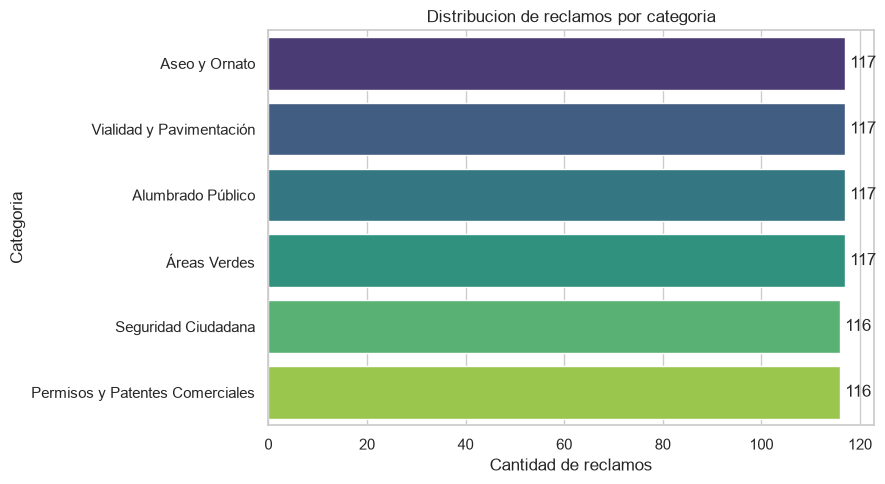

In [4]:
category_counts = df["categoria"].value_counts()
print(category_counts)
print()
print("Porcentaje por categoria:")
print((category_counts / len(df) * 100).round(2).astype(str) + " %")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    x=category_counts.values, y=category_counts.index,
    hue=category_counts.index, palette="viridis", legend=False, ax=ax,
)
ax.set_xlabel("Cantidad de reclamos")
ax.set_ylabel("Categoria")
ax.set_title("Distribucion de reclamos por categoria")
for i, v in enumerate(category_counts.values):
    ax.text(v + 1, i, str(v), va="center")
plt.tight_layout()
plt.show()


**Hallazgo:** el dataset esta prácticamente balanceado (116-117 registros por
categoría, ~14.3% cada una sobre 700 totales). Esto significa que **no se
requieren técnicas de rebalanceo** (SMOTE, undersampling, `class_weight`) y
que la accuracy global es una métrica razonable de referencia, aunque de
todas formas se reportará precision/recall/F1 por categoría en la evaluación
final (ver `models/metrics.json`), ya que el balance del dataset sintético no
garantiza que el modelo aprenda igual de bien las 6 categorías.


## 4. Longitud de los textos (caracteres y palabras)

La longitud de los reclamos es relevante para decidir el enfoque de
vectorización: textos muy cortos favorecen TF-IDF sobre representaciones que
necesitan secuencias largas (RNN/Transformers) para funcionar bien.


In [5]:
df["n_caracteres"] = df["texto"].str.len()
df["n_palabras"] = df["texto"].str.split().str.len()

df[["n_caracteres", "n_palabras"]].describe().round(1)


,n_caracteres,n_palabras
count,700.0,700.0
mean,159.7,28.5
std,17.3,3.5
min,100.0,18.0
25%,149.8,26.0
50%,161.0,29.0
75%,172.0,31.0
max,203.0,38.0


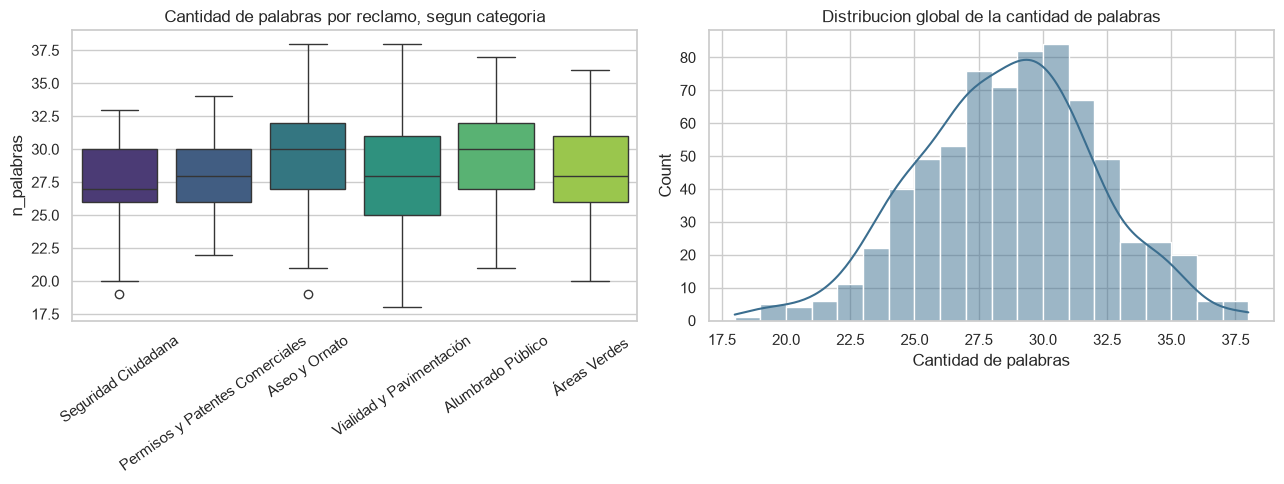

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=df, x="categoria", y="n_palabras",
    hue="categoria", palette="viridis", legend=False, ax=axes[0],
)
axes[0].set_title("Cantidad de palabras por reclamo, segun categoria")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)

sns.histplot(df["n_palabras"], bins=20, kde=True, ax=axes[1], color="#3b6e8f")
axes[1].set_title("Distribucion global de la cantidad de palabras")
axes[1].set_xlabel("Cantidad de palabras")

plt.tight_layout()
plt.show()


**Hallazgo:** los reclamos son cortos (predominan entre ~15 y ~30 palabras) y
la distribución es similar entre categorías -- es decir, **la longitud del
texto no es un atajo trivial** que el modelo pueda usar para adivinar la
categoría sin leer el contenido. Esto confirma que el problema requiere
analizar el vocabulario, no solo estadísticas superficiales del texto, y
refuerza la elección de un enfoque de bolsa de palabras ponderada (TF-IDF)
en lugar de arquitecturas de deep learning que solo se justifican con
secuencias largas y datasets de mayor volumen.


## 5. Normalización del texto

El dataset fue generado simulando cómo escribe un vecino real: sin tildes en
gran parte de los casos, con mezcla de mayúsculas/minúsculas y abreviaturas
coloquiales (`xq`, `q`, `pq`). Antes de analizar el vocabulario se aplica una
normalización simple (minúsculas, sin tildes, sin signos de puntuación) que
luego se reutilizará tal cual en `src/train.py` como parte del pipeline de
preprocesamiento.


In [7]:
def normalize_text(text: str) -> str:
    """Normaliza el texto: minusculas, sin tildes y sin signos de puntuacion."""
    text = text.lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(char for char in text if not unicodedata.combining(char))
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["texto_normalizado"] = df["texto"].apply(normalize_text)
df[["texto", "texto_normalizado"]].sample(5, random_state=42)


,texto,texto_normalizado
158,"hace tiempo que pedimos mas alumbrado en el pasaje de Poblacion El Bosque, esta todo oscuro y varias vecinas tienen ...",hace tiempo que pedimos mas alumbrado en el pasaje de poblacion el bosque esta todo oscuro y varias vecinas tienen m...
500,"hola municipio, hay un colchon y varios muebles viejos botados hace 20 dias en la esquina, porfavor manden a retirar...",hola municipio hay un colchon y varios muebles viejos botados hace 20 dias en la esquina porfavor manden a retirarlo...
396,"buen dia, el pasto y la maleza de la vereda en calle San Martin ya casi tapan la calzada, ademas hay bastante basura...",buen dia el pasto y la maleza de la vereda en calle san martin ya casi tapan la calzada ademas hay bastante basura a...
155,"Buen dia, el bar que esta cerca de mi casa en Villa El Trebol hace un ruido tremendo todos los fines de semana hasta...",buen dia el bar que esta cerca de mi casa en villa el trebol hace un ruido tremendo todos los fines de semana hasta ...
321,"el juego de resbalin de la plaza del sector oriente esta oxidado y con el fierro filoso, ya casi corta a un nino. Qu...",el juego de resbalin de la plaza del sector oriente esta oxidado y con el fierro filoso ya casi corta a un nino qued...


## 6. Palabras más frecuentes (global y por categoría)

Para identificar el vocabulario relevante se remueven las *stopwords* del
español (artículos, preposiciones, pronombres, etc.). Scikit-learn no trae una
lista de stopwords en español incorporada (solo inglés), por lo que se define
una lista propia con las palabras funcionales más comunes.


In [8]:
SPANISH_STOPWORDS = sorted(set('''
a al algo algunas algunos ante antes como con contra cual cuando de del desde
donde durante e el ella ellas ellos en entre era erais eramos eran eres es esa
esas ese esos esta estas este estos ha hay la las le les lo los mas me mi mis
mucho muchos muy nada ni no nos nosotros o os otra otras otro otros para pero
poco por porque que quien quienes se sin sobre su sus te tu tus un una uno
unos vosotros y ya yo
'''.split()))

print(f"Cantidad de stopwords definidas: {len(SPANISH_STOPWORDS)}")


Cantidad de stopwords definidas: 88


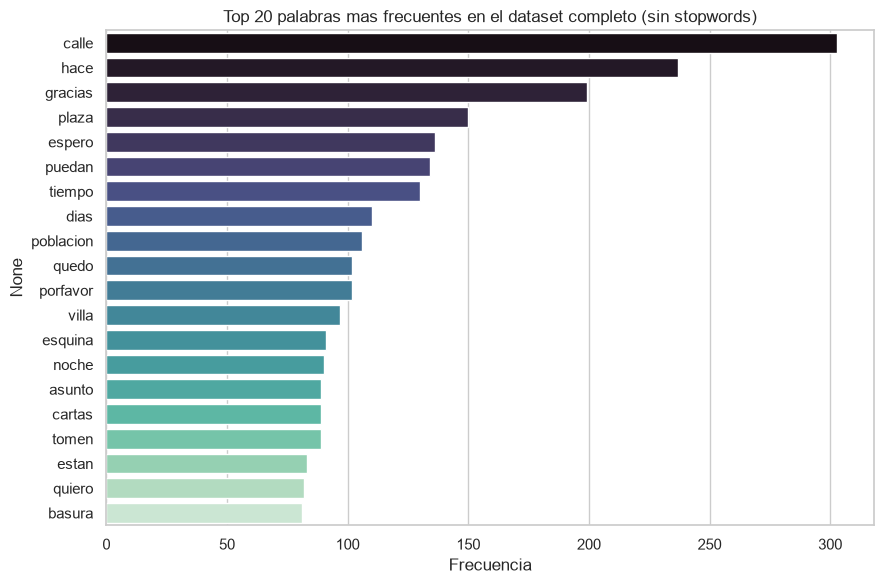

In [9]:
vectorizer = CountVectorizer(stop_words=SPANISH_STOPWORDS, max_features=20)
word_matrix = vectorizer.fit_transform(df["texto_normalizado"])
word_freq = pd.Series(
    word_matrix.toarray().sum(axis=0), index=vectorizer.get_feature_names_out()
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    x=word_freq.values, y=word_freq.index,
    hue=word_freq.index, palette="mako", legend=False, ax=ax,
)
ax.set_title("Top 20 palabras mas frecuentes en el dataset completo (sin stopwords)")
ax.set_xlabel("Frecuencia")
plt.tight_layout()
plt.show()


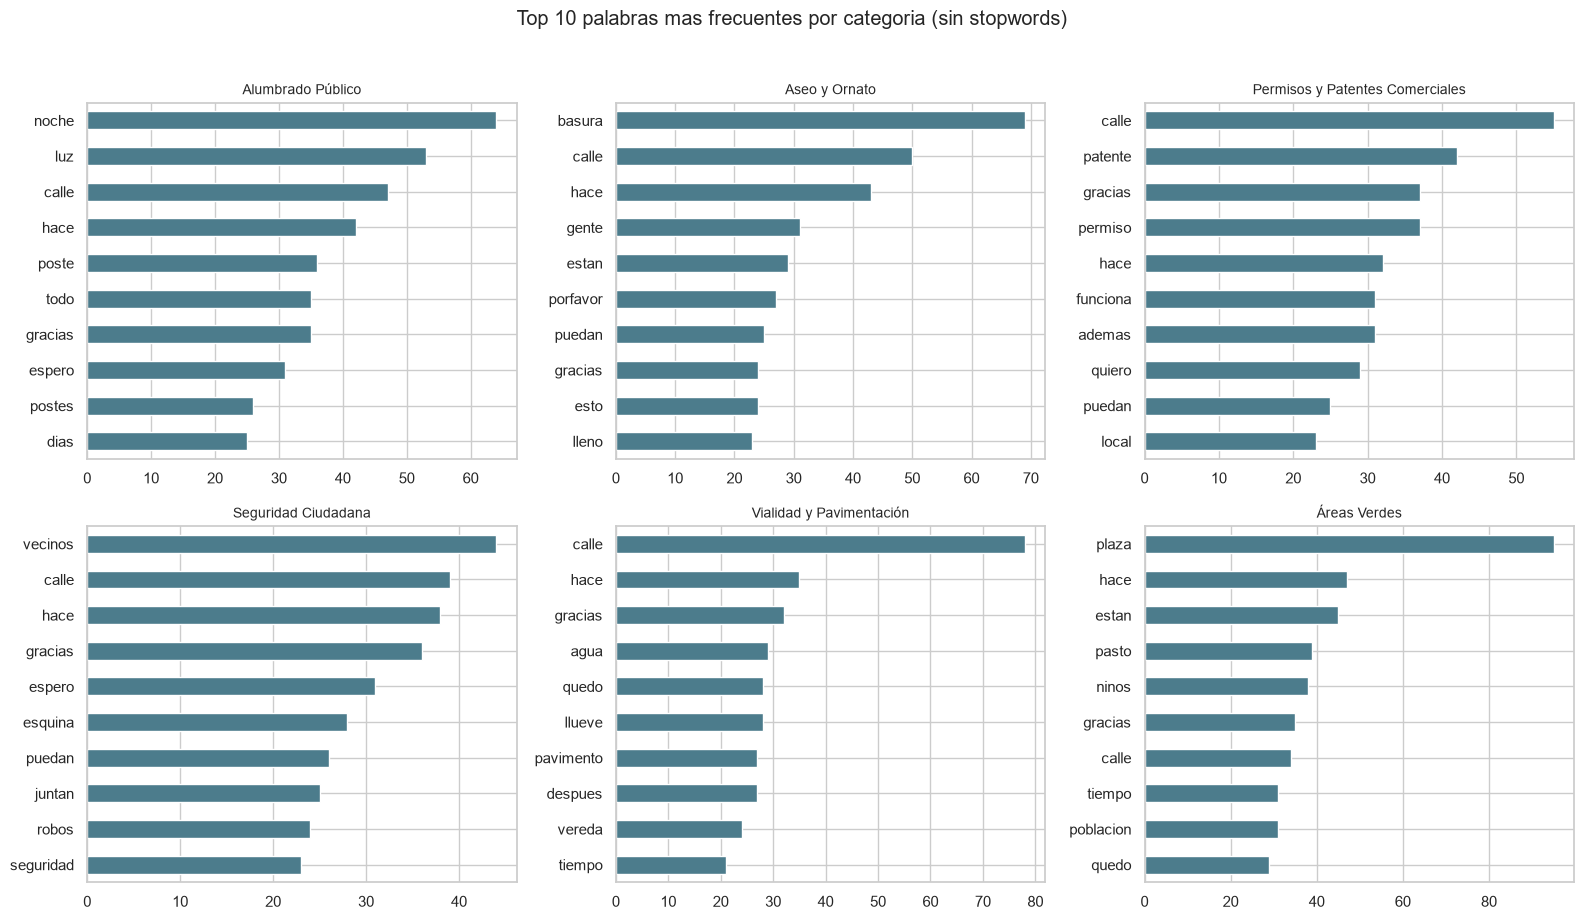

In [10]:
categories = sorted(df["categoria"].unique())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, category in zip(axes, categories):
    subset = df.loc[df["categoria"] == category, "texto_normalizado"]
    vec = CountVectorizer(stop_words=SPANISH_STOPWORDS, max_features=10)
    matrix = vec.fit_transform(subset)
    freq = pd.Series(
        matrix.toarray().sum(axis=0), index=vec.get_feature_names_out()
    ).sort_values()
    freq.plot(kind="barh", ax=ax, color="#4c7c8c")
    ax.set_title(category, fontsize=10)

fig.suptitle("Top 10 palabras mas frecuentes por categoria (sin stopwords)", y=1.02)
plt.tight_layout()
plt.show()


**Hallazgo:** cada categoría tiene un vocabulario claramente identificable
(p. ej. *basura / contenedor / camion* en Aseo y Ornato, *hoyo / pavimento /
vereda* en Vialidad y Pavimentación, *poste / luminaria / foco* en Alumbrado
Público, *plaza / pasto / arbol* en Áreas Verdes, *robos / seguridad / drogas*
en Seguridad Ciudadana, *patente / permiso / negocio* en Permisos y Patentes
Comerciales). Esto confirma que un enfoque de **bolsa de palabras** es
adecuado para este problema: no hace falta capturar relaciones semánticas
complejas ni orden de las palabras para distinguir las categorías.


## 7. Solapamiento de vocabulario entre categorías

Algunas categorías comparten temática (por ejemplo, *Aseo y Ornato* y *Áreas
Verdes* mencionan pasto y plazas). Medir el solapamiento del vocabulario más
frecuente ayuda a anticipar en qué pares de categorías el modelo podría
confundirse, algo que luego se debe revisar explícitamente en la matriz de
confusión del modelo entrenado.


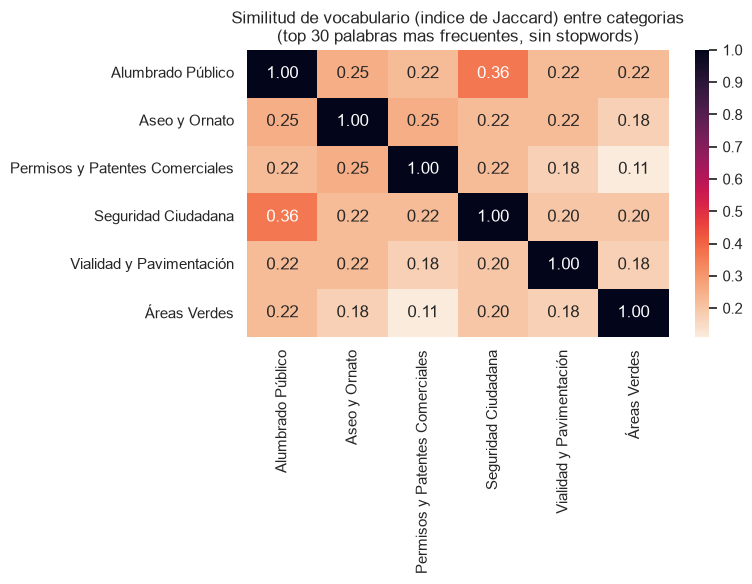

In [11]:
top_words_by_category = {}
for category in categories:
    subset = df.loc[df["categoria"] == category, "texto_normalizado"]
    vec = CountVectorizer(stop_words=SPANISH_STOPWORDS, max_features=30)
    vec.fit(subset)
    top_words_by_category[category] = set(vec.get_feature_names_out())

jaccard = pd.DataFrame(index=categories, columns=categories, dtype=float)
for cat_a in categories:
    for cat_b in categories:
        inter = len(top_words_by_category[cat_a] & top_words_by_category[cat_b])
        union = len(top_words_by_category[cat_a] | top_words_by_category[cat_b])
        jaccard.loc[cat_a, cat_b] = inter / union if union else 0.0

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(jaccard, annot=True, fmt=".2f", cmap="rocket_r", ax=ax)
ax.set_title("Similitud de vocabulario (indice de Jaccard) entre categorias\n(top 30 palabras mas frecuentes, sin stopwords)")
plt.tight_layout()
plt.show()


**Hallazgo:** la diagonal es 1.0 (cada categoría es idéntica a sí misma) y los
valores fuera de la diagonal son bajos, lo que confirma que las 6 categorías
son lexicalmente distinguibles. El mayor solapamiento esperable ocurre entre
categorías temáticamente cercanas (p. ej. *Aseo y Ornato* / *Áreas Verdes*).
Esto justifica usar **TF-IDF** en lugar de conteos simples: TF-IDF reduce el
peso de palabras que aparecen en muchas categorías y resalta los términos
realmente distintivos de cada una.


## 8. Conclusiones del EDA

- El dataset sintético (700 registros, 6 categorías) está **balanceado**
  (~14.3% por categoría), sin valores nulos ni registros duplicados.
- Los reclamos son **textos cortos** (mayoría entre 15 y 30 palabras) con
  redacción informal (sin tildes, abreviaturas tipo `xq`/`q`), lo que exige
  una etapa explícita de normalización de texto antes de vectorizar.
- La longitud del texto es similar entre categorías, por lo que **no hay
  atajos triviales**: el modelo debe aprender del vocabulario real.
- Cada categoría tiene un vocabulario propio y reconocible, con solapamiento
  bajo mayoritariamente entre categorías temáticamente relacionadas.

**Implicancias para el diseño del modelo** (detalladas en `README.md`):

1. Preprocesamiento: minúsculas + eliminación de tildes/puntuación (igual que
   en este notebook), reutilizado en `src/train.py`.
2. Vectorización: **TF-IDF**, que pondera mejor que un conteo simple dado el
   solapamiento de vocabulario detectado entre categorías.
3. Modelo: **Naive Bayes multinomial o Logistic Regression** — scikit-learn es
   suficiente y más eficiente en inferencia que una red neuronal, dado el
   volumen de datos (~700 registros) y la naturaleza discreta del problema.
4. Evaluación: además de accuracy, se debe reportar **precision/recall/F1 por
   categoría** y revisar la matriz de confusión prestando especial atención a
   los pares de categorías con mayor solapamiento de vocabulario detectado en
   la sección 7.
